In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import src.data_io as data
import src.cleaning as cleaner
from src.config import load_config, update_config

In [3]:
config = load_config()
data_path = f"{config['paths']['raw_data']}/{config['files']['raw_dataset']}"

In [4]:
df = data.load_dataset(f'{data_path}.csv')

# Dataset Overview

In [5]:
df.shape

(1360, 16)

In [6]:
df.head()

,year,month,country,region,student_ai_usage_pct,teacher_ai_usage_pct,schools_ai_adoption_pct,avg_daily_ai_usage_min,top_ai_tool,internet_penetration_pct,education_index,government_ai_policy,urban_ai_usage_pct,rural_ai_usage_pct,ai_in_curriculum,gender_gap_ai_usage_pct
0,2015,1,United States,North America,1,2,1,19,Google Gemini,90,0.90,NaN,1,0,Yes,6
1,2015,1,United Kingdom,Europe,4,1,5,11,Google Gemini,92,0.91,Draft,7,0,Yes,5
2,2015,1,China,Asia,6,5,4,7,ChatGPT,70,0.75,Active,8,1,No,7
3,2015,1,India,Asia,7,5,0,59,Microsoft Copilot,50,0.64,NaN,10,0,Yes,7
4,2015,1,Germany,Europe,9,7,6,29,Khanmigo,93,0.94,Active,13,0,Yes,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1360 entries, 0 to 1359
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   year                      1360 non-null   int64  
 1   month                     1360 non-null   int64  
 2   country                   1360 non-null   object 
 3   region                    1360 non-null   object 
 4   student_ai_usage_pct      1360 non-null   int64  
 5   teacher_ai_usage_pct      1360 non-null   int64  
 6   schools_ai_adoption_pct   1360 non-null   int64  
 7   avg_daily_ai_usage_min    1360 non-null   int64  
 8   top_ai_tool               1360 non-null   object 
 9   internet_penetration_pct  1360 non-null   int64  
 10  education_index           1360 non-null   float64
 11  government_ai_policy      919 non-null    object 
 12  urban_ai_usage_pct        1360 non-null   int64  
 13  rural_ai_usage_pct        1360 non-null   int64  
 14  ai_in_cu

There seems to be missing values in `government_ai_policy` column. This needs further checking to decide on the action to be taken.

### Data Quality Assessment

In [8]:
print("Null columns:\n", cleaner.check_null_columns(df), sep="")

Null columns:
                      null_count   null_pct
government_ai_policy         441  32.426471


In [9]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [10]:
obj_cols, num_cols = cleaner.check_column_type(df)
print(f"Object Data Columns:\n{obj_cols}\n\nNumerical Data Columns:\n{num_cols}")

Object Data Columns:
['country', 'region', 'top_ai_tool', 'government_ai_policy', 'ai_in_curriculum']

Numerical Data Columns:
['year', 'month', 'student_ai_usage_pct', 'teacher_ai_usage_pct', 'schools_ai_adoption_pct', 'avg_daily_ai_usage_min', 'internet_penetration_pct', 'education_index', 'urban_ai_usage_pct', 'rural_ai_usage_pct', 'gender_gap_ai_usage_pct']


In [11]:
num_cols = [col for col in num_cols if col != 'month']
obj_cols.append('month')

In [12]:
print(f"Object Data Columns:\n{obj_cols}\n\nNumerical Data Columns:\n{num_cols}")

Object Data Columns:
['country', 'region', 'top_ai_tool', 'government_ai_policy', 'ai_in_curriculum', 'month']

Numerical Data Columns:
['year', 'student_ai_usage_pct', 'teacher_ai_usage_pct', 'schools_ai_adoption_pct', 'avg_daily_ai_usage_min', 'internet_penetration_pct', 'education_index', 'urban_ai_usage_pct', 'rural_ai_usage_pct', 'gender_gap_ai_usage_pct']


In [13]:
for col in obj_cols:
    print(col, "\n", df[col].unique(), "\n", sep="")

country
['United States' 'United Kingdom' 'China' 'India' 'Germany' 'Brazil'
 'Pakistan' 'Nigeria' 'Canada' 'Australia']

region
['North America' 'Europe' 'Asia' 'South America' 'Africa' 'Oceania']

top_ai_tool
['Google Gemini' 'ChatGPT' 'Microsoft Copilot' 'Khanmigo']

government_ai_policy
[nan 'Draft' 'Active']

ai_in_curriculum
['Yes' 'No']

month
[ 1  2  3  4  5  6  7  8  9 10 11 12]



array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'student_ai_usage_pct'}>,
        <Axes: title={'center': 'teacher_ai_usage_pct'}>],
       [<Axes: title={'center': 'schools_ai_adoption_pct'}>,
        <Axes: title={'center': 'avg_daily_ai_usage_min'}>,
        <Axes: title={'center': 'internet_penetration_pct'}>],
       [<Axes: title={'center': 'education_index'}>,
        <Axes: title={'center': 'urban_ai_usage_pct'}>,
        <Axes: title={'center': 'rural_ai_usage_pct'}>],
       [<Axes: title={'center': 'gender_gap_ai_usage_pct'}>, <Axes: >,
        <Axes: >]], dtype=object)

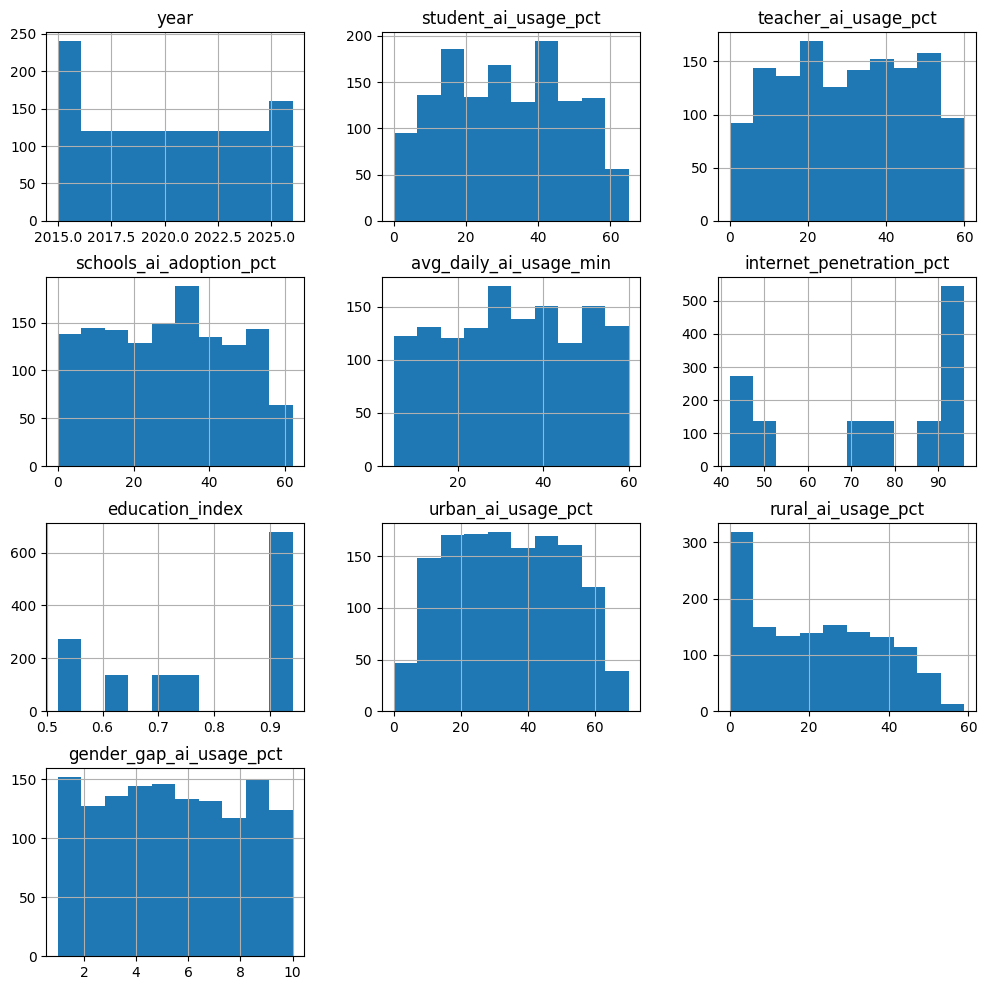

In [14]:
df[num_cols].hist(figsize=(12,12))

In [15]:
df.describe()

,year,month,student_ai_usage_pct,teacher_ai_usage_pct,schools_ai_adoption_pct,avg_daily_ai_usage_min,internet_penetration_pct,education_index,urban_ai_usage_pct,rural_ai_usage_pct,gender_gap_ai_usage_pct
count,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000,1360.000000
mean,2020.176471,6.382353,30.986765,29.907353,29.409559,32.823529,74.700000,0.776000,33.561765,21.600735,5.412500
std,3.277417,3.473984,16.704455,16.459246,16.603742,15.561921,20.691177,0.156978,16.757123,16.185691,2.876101
min,2015.000000,1.000000,0.000000,0.000000,0.000000,5.000000,42.000000,0.520000,0.000000,0.000000,1.000000
25%,2017.000000,3.000000,17.000000,16.000000,15.000000,20.000000,50.000000,0.640000,20.000000,7.000000,3.000000
50%,2020.000000,6.000000,31.000000,30.000000,29.500000,33.000000,82.500000,0.825000,33.000000,21.000000,5.000000
75%,2023.000000,9.000000,45.000000,44.000000,43.000000,46.000000,93.000000,0.920000,47.000000,35.000000,8.000000
max,2026.000000,12.000000,65.000000,60.000000,62.000000,60.000000,96.000000,0.940000,70.000000,59.000000,10.000000


#### Observations:
- `government_ai_tool` column has 32% null values.
- `month` column is being analysed as a numerical column.
- Values of `month` columns are numerical values.
- `internet_penetration_pct` and `education_index` have discrete values.
- There seems to be no outlier present in the data.

#### Implications:
- 32% null values is comparatively a large portion of the data, thus their rows can not be removed.
- Incorrect data type of `month` column may result in it being included in analytical summaries.
- Numerical values for `month` represents the issue. When importing the dataset, these values resulted in the data type of the column be set as numerical.
- Discrete values means that explicit trends and patterns cannot be find from the data including them.
- No outliers means that the results will be more accurate than biased.

#### Actions:
- Null values in `government_ai_policy` need to be imputed.
- The numerical values of `month` column needs to be mapped to their corresponding months.

# Data Cleaning

In [16]:
df = cleaner.fill_null(df, {'government_ai_policy': 'Unknown'})

In [17]:
month_map = {
    'month': {
        1: "January", 2: "February", 3: "March", 4: "April",
        5: "May", 6: "June", 7: "July", 8: "August",
        9: "September", 10: "October", 11: "November", 12: "December"
    },
    'country': {
        "United Kingdom": "UK",
        "United States": "US"
    }
}

df = cleaner.apply_mapping(df, month_map)

In [18]:
df = df.drop('region', axis=1)

In [19]:
save_path = f'{config['paths']['processed_data']}/{config['files']['raw_dataset']}_processed.csv'
data.save_dataset(df, save_path)

In [20]:
update_config('files', 'processed_dataset', f'{config['files']['raw_dataset']}_processed')

Updated [files] -> processed_dataset: ai_education_usage_global_processed


#### Observations:
- The null values in `government_ai_policy` have been replaced by 'Unknown'.
- The numerical values for the `month` columns have been mapped to their corresponding month names.
- The `region` column was because of inconsistency in number of countries in each region.

#### Implications:
These steps will make the analytical results more accurate.